# 02 — Confirm box size visually

The size decision is already made (`box_px = 14`: a car is ~18x7 px at 25 cm, and 24 px @15 cm scales to ~14 px). This notebook is the **visual double-check** — actually seeing a 14 px box sit on a real car — not a fresh decision.

**What you're checking:** boxes land *on* cars (not offset → coordinate bug); 14 px covers the car without routinely **swallowing the neighbour** in a tight row; and it isn't so small it sits inside the car. If 14 looks wrong, the size-comparison cell shows 12/13/14/16 side by side so you can repick — then update `configs/cowc.yaml` and re-tile.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.resample import resolution_scale, resample_image
from src.annotations import extract_points_from_mask, find_car_mask, scale_points

# --- the scene to check against (any RGB scene is more representative; Vaihingen
# --- is what we have tiled, so it's a fine first look) ----------------------
SCENE_IMG = PROJECT_ROOT / (
    "data/cowc/raw/cowc/datasets/ground_truth_sets/"
    "Vaihingen_ISPRS/TOP_Mosaic_09cm_scaled_15cm_Gray.png"
)
SOURCE_CM, TARGET_CM = 15.0, 25.0
BOX_PX = 14            # the locked value we are confirming visually

In [2]:
# Downsample the scene to 25 cm and bring the car points to the same coords.
scale = resolution_scale(SOURCE_CM, TARGET_CM)
img25 = resample_image(Image.open(SCENE_IMG).convert("RGB"), scale)
xs, ys = extract_points_from_mask(find_car_mask(SCENE_IMG))
xs, ys = scale_points(xs, ys, scale)
print(f"scene at 25 cm: {img25.size}, cars: {len(xs)}, box_px = {BOX_PX}")

scene_arr = np.asarray(img25)

scene at 25 cm: (7290, 7668), cars: 2863, box_px = 14


### Zoomed overlay (full tiles are too zoomed-out to judge a 14 px box)

In [3]:
def show_boxes_at(cx, cy, half_window=90, box_px=BOX_PX, ax=None):
    """Zoom to a (2*half_window) crop centred on (cx, cy) and draw a `box_px`
    square on every car centre inside it. A full tile is too zoomed-out to judge
    a 14 px box, so always inspect a crop."""
    x0, y0 = max(cx - half_window, 0), max(cy - half_window, 0)
    x1 = min(cx + half_window, scene_arr.shape[1])
    y1 = min(cy + half_window, scene_arr.shape[0])

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(scene_arr[y0:y1, x0:x1])

    in_crop = (xs >= x0) & (xs < x1) & (ys >= y0) & (ys < y1)
    h = box_px / 2.0
    for x, y in zip(xs[in_crop], ys[in_crop]):
        ax.add_patch(patches.Rectangle(
            (x - x0 - h, y - y0 - h), box_px, box_px,
            linewidth=1.2, edgecolor="lime", facecolor="none"))
    ax.set_title(f"{int(in_crop.sum())} cars | box_px={box_px}", fontsize=9)
    ax.axis("off")
    return ax


def densest_centre(cell=160):
    """Centre of the densest `cell`-sized bin of car points -- the tight-row
    case where box size matters most. O(n) via a 2D histogram."""
    if len(xs) == 0:
        return 0, 0
    xe = np.arange(xs.min(), xs.max() + cell + 1, cell)
    ye = np.arange(ys.min(), ys.max() + cell + 1, cell)
    if len(xe) < 2:
        xe = np.array([xs.min(), xs.min() + cell])
    if len(ye) < 2:
        ye = np.array([ys.min(), ys.min() + cell])
    H, _, _ = np.histogram2d(xs, ys, bins=[xe, ye])
    i, j = np.unravel_index(int(np.argmax(H)), H.shape)
    # centre on the MEAN of the points in the densest cell, so cars are centred
    # in the crop (the cell's geometric centre can sit off the actual points).
    in_cell = ((xs >= xe[i]) & (xs < xe[i + 1]) &
               (ys >= ye[j]) & (ys < ye[j + 1]))
    return int(xs[in_cell].mean()), int(ys[in_cell].mean())

### The hard test: densest cluster (tight rows are where box size shows)

densest cluster near: (3173, 5188)


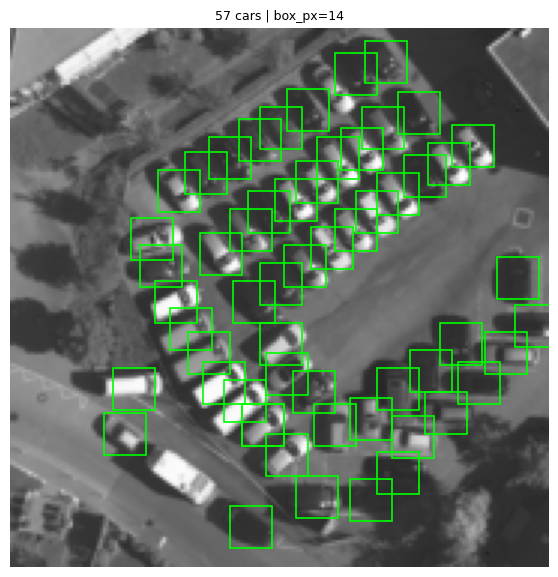

In [4]:
# Auto-jump to the densest cluster and inspect box fit there.
cx, cy = densest_centre()
print("densest cluster near:", (cx, cy))
show_boxes_at(cx, cy, half_window=90)
plt.show()

### Size comparison — only act on this if 14 px looked wrong above

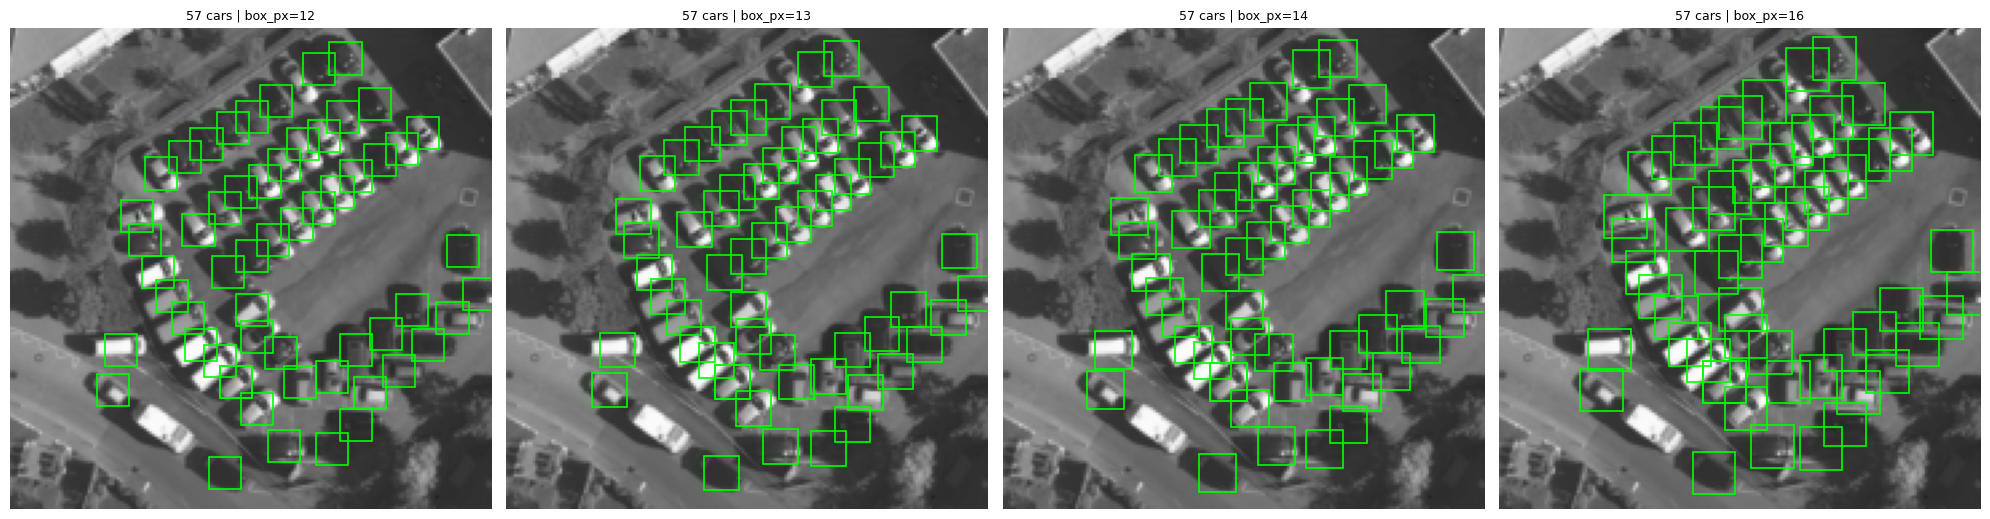

In [5]:
# Side-by-side size comparison at the same cluster, in case 14 looks off.
# If 14 swallows neighbours, drop to 12/13; if cars look loosely boxed, go up.
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, bp in zip(axes, (12, 13, 14, 16)):
    show_boxes_at(cx, cy, half_window=90, box_px=bp, ax=ax)
plt.tight_layout(); plt.show()

### An edge cluster — confirm boxes land correctly near the scene boundary

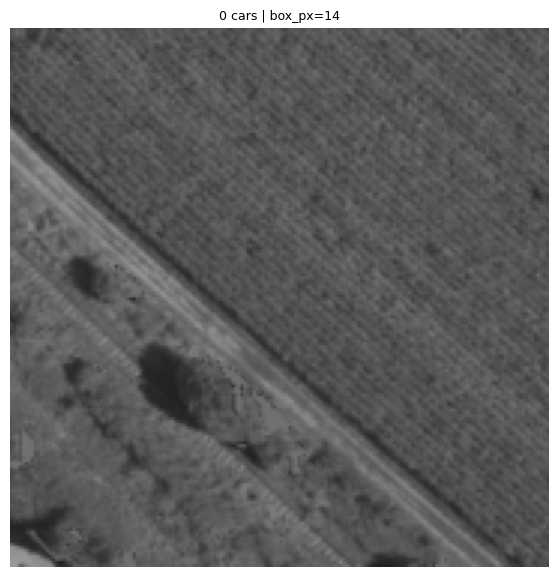

In [6]:
# Sanity: a cluster near the scene's right/bottom edge, to confirm boxes on
# edge cars sit correctly (clipping is handled per-tile in build, but this shows
# the points land where expected). Move the centre if it's over no-data.
ex = int(xs.max() - 60); ey = int(ys[xs > xs.max() - 200].mean())
show_boxes_at(ex, ey, half_window=90)
plt.show()

**If 14 px looks right:** nothing to change — it's already locked in the config; proceed to `build_cowc.py`. **If not:** pick the best size from the comparison, set `box_px` in `configs/cowc.yaml`, clear `processed/images/test_tiling`, and re-run the tiling test before building.